# Polynomial Regression

The goal is to predict the numerical disease progression target using multiple input features.

Polynomial Regression is used to capture non-linear relationships by creating polynomial and interaction features from the original features.

Since polynomial features can make the model complex and cause overfitting, Ridge regularization and GridSearchCV are used to find a suitable polynomial degree and regularization strength.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [18]:
df = pd.read_csv("../Dataset/diabetes.csv")

In [19]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [20]:
df.shape

(442, 11)

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [22]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [23]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


## Separate Features and Target

The `target` column is the value we want to predict.

The remaining columns are used as input features.

In [24]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
target


In [25]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


## Train-Test Split

The dataset is divided into training and testing data.

80% of the data is used for training and 20% is used for testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [27]:
train_data = X_train.copy()
train_data["target"] = y_train
train_correlation = train_data.corr()["target"].drop("target")
print("Correlation with target:")
print(train_correlation.sort_values(ascending=False))

Correlation with target:
bmi    0.604751
s5     0.552183
bp     0.444770
s4     0.425094
s6     0.390363
s1     0.199547
age    0.196510
s2     0.154922
sex    0.007116
s3    -0.384000
Name: target, dtype: float64


In [28]:
X_train = X_train.drop(columns=["sex"])
X_test = X_test.drop(columns=["sex"])
print("Features used:")
print(X_train.columns.tolist())

Features used:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [40]:
degrees = [1, 2, 3]
alphas = [0.01, 0.1, 1, 10, 100]
best_model = None
best_poly = None
best_degree = None
best_alpha = None
best_score = -np.inf

grid_results = []

for degree in degrees:

    poly = PolynomialFeatures(degree=degree,  include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    ridge = Ridge()
    grid = GridSearchCV(ridge, {"alpha": alphas}, cv=5, scoring="r2")
    grid.fit(X_train_poly, y_train)
    grid_results.append({
        "Degree": degree,
        "Best Alpha": grid.best_params_["alpha"],
        "CV R²": grid.best_score_
    })
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_poly = poly
        best_degree = degree
        best_alpha = grid.best_params_["alpha"]
grid_results = pd.DataFrame(grid_results)
grid_results

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.423815281777285e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5801404090927048e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.8357553809689204e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 

,Degree,Best Alpha,CV R²
0,1,1,0.432507
1,2,100,0.353977
2,3,100,-6.262082


In [41]:
print("Best Polynomial Degree:", best_degree)
print("Best Ridge Alpha:", best_alpha)
print("Best Cross-Validation R²:", round(best_score, 4))

Best Polynomial Degree: 1
Best Ridge Alpha: 1
Best Cross-Validation R²: 0.4325


In [42]:
X_test_poly = best_poly.transform(X_test)

print("Training polynomial data:", best_poly.transform(X_train).shape)
print("Testing polynomial data:", X_test_poly.shape)

Training polynomial data: (353, 9)
Testing polynomial data: (89, 9)


In [43]:
y_pred = best_model.predict(X_test_poly)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[130.71350687 169.10795678 153.47481378 266.28373512 132.47180809
  87.29231998 276.25591797 198.83466563 101.55812278 126.67573351]


In [44]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,219.0,130.713507
1,70.0,169.107957
2,202.0,153.474814
3,230.0,266.283735
4,111.0,132.471808
5,84.0,87.292320
6,242.0,276.255918
7,272.0,198.834666
8,94.0,101.558123
9,96.0,126.675734


In [45]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 44.3147
MSE : 2987.2464
RMSE: 54.6557
R²  : 0.4362


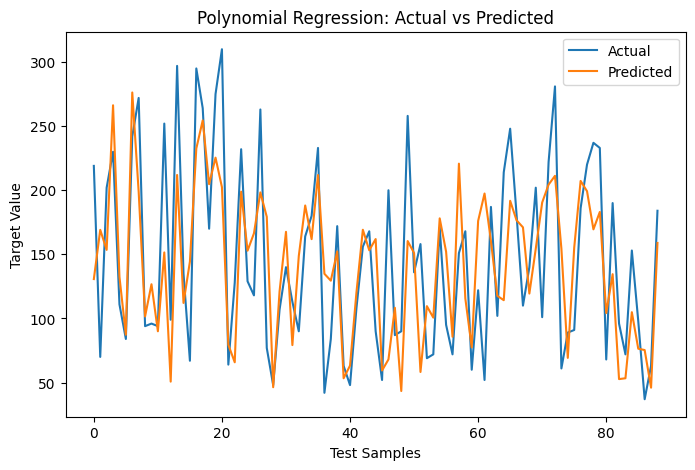

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Target Value")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.legend()

plt.show()

In [47]:
print("Polynomial Regression")
print("\nBest Polynomial Degree:", best_degree)
print("Best Ridge Alpha:", best_alpha)
print("Features Used:", X_train.columns.tolist())
print("Best CV R²:", round(best_score, 4))
print("Test MAE :", round(mae, 4))
print("Test MSE :", round(mse, 4))
print("Test RMSE:", round(rmse, 4))
print("Test R²   :", round(r2, 4))

Polynomial Regression

Best Polynomial Degree: 1
Best Ridge Alpha: 1
Features Used: ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Best CV R²: 0.4325
Test MAE : 44.3147
Test MSE : 2987.2464
Test RMSE: 54.6557
Test R²   : 0.4362
